In [1]:
import pandas as pd #Biblioteca para Dataframes (planilhas)
import numpy as np #Para operações matemáticas

import io
from google.colab import files

import matplotlib.pyplot as plt #matplotlib desenha gráficos
import matplotlib.colors as colors
from sklearn.utils import resample #sklearn trabalha com a implementação de algoritmos ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import AdaBoostRegressor
from datetime import date, datetime

In [126]:
from collections import defaultdict
for i in range(2010,2025,1):

  url = "https://info.dengue.mat.br/api/alertcity"
  geocode = 2927408
  disease = "dengue"
  format = "csv"
  ew_start = 1
  ew_end = 53
  ey_start = i
  ey_end = i

  params =(
      "&disease="
      + f"{disease}"
      + "&geocode="
      + f"{geocode}"
      + "&disease="
      + f"{disease}"
      + "&format="
      + f"{format}"
      + "&ew_start="
      + f"{ew_start}"
      + "&ew_end="
      + f"{ew_end}"
      + "&ey_start="
      + f"{ey_start}"
      + "&ey_end="
      + f"{ey_end}"
  )

  url_resp = "?".join([url, params])
  if i == 2010:
    df = pd.read_csv(url_resp, index_col='SE')
  else:
    dadosNew = pd.read_csv(url_resp, index_col='SE')
    df = pd.concat([dadosNew, df])
df

,data_iniSE,casos_est,casos_est_min,casos_est_max,casos,p_rt1,p_inc100k,Localidade_id,nivel,id,...,umidmed,umidmin,tempmed,tempmax,casprov,casprov_est,casprov_est_min,casprov_est_max,casconf,notif_accum_year
SE,,,,,,,,,,,,,,,,,,,,,
202452,2024-12-22,73.0,62,97,57,0.103874,2.795878,0,2,292740820245220102,...,71.798614,57.208857,27.210786,29.865657,51.0,NaN,NaN,NaN,NaN,17149
202451,2024-12-15,85.0,78,100,75,0.327967,3.255474,0,2,292740820245120102,...,76.152914,61.899214,27.340871,29.881429,57.0,NaN,NaN,NaN,NaN,17149
202450,2024-12-08,92.0,86,101,85,0.571018,3.523572,0,2,292740820245020102,...,75.247514,60.179486,26.838543,29.448471,59.0,NaN,NaN,NaN,NaN,17149
202449,2024-12-01,93.0,89,100,89,0.665832,3.561872,0,2,292740820244920102,...,76.685514,61.395171,26.418671,28.997471,52.0,NaN,NaN,NaN,NaN,17149
202448,2024-11-24,90.0,87,95,87,0.524782,3.446972,0,2,292740820244820102,...,83.354843,75.817857,25.653100,27.281543,59.0,NaN,NaN,NaN,NaN,17149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201005,2010-01-31,118.0,118,118,118,0.000000,4.087716,0,2,292740820100519589,...,74.697437,60.142857,28.655242,31.285714,NaN,NaN,NaN,NaN,NaN,9227
201004,2010-01-24,69.0,69,69,69,0.000000,2.390274,0,2,292740820100419589,...,76.221839,61.857143,28.148011,30.857143,NaN,NaN,NaN,NaN,NaN,9227
201003,2010-01-17,57.0,57,57,57,0.000000,1.974574,0,2,292740820100319589,...,80.623241,66.857143,27.698323,30.142857,NaN,NaN,NaN,NaN,NaN,9227


In [127]:
df['data_iniSE'] = pd.to_datetime(df['data_iniSE'])
df = df.loc[:, ['data_iniSE', 'casos', 'pop', 'umidmed', 'tempmed']]
df = df.iloc[::-1] #Inverte a ordem das linhas
OG_df = df.copy()
df

,data_iniSE,casos,pop,umidmed,tempmed
SE,,,,,
201001,2010-01-03,60,2886698,82.989629,27.444322
201002,2010-01-10,52,2886698,82.638528,27.503644
201003,2010-01-17,57,2886698,80.623241,27.698323
201004,2010-01-24,69,2886698,76.221839,28.148011
201005,2010-01-31,118,2886698,74.697437,28.655242
...,...,...,...,...,...
202448,2024-11-24,87,2610987,83.354843,25.653100
202449,2024-12-01,89,2610987,76.685514,26.418671
202450,2024-12-08,85,2610987,75.247514,26.838543


In [93]:
def create_time_series_variables(df, columns, time_periods):
    """
    Create time-series variables for specified columns and time periods.

    Parameters:
    - df: pd.DataFrame
        The input DataFrame containing the data.
    - columns: list of str
        List of column names to create time-series variables for.
    - time_periods: list of int
        List of time periods (in weeks) to create lagged variables for.

    Returns:
    - pd.DataFrame
        DataFrame with original data and time-series variables added.
    """
    df = df.copy()  # Avoid modifying the original DataFrame

    for col in columns:
        for period in time_periods:
            lag_col_name = f"{col}_lag_{period}w"
            df[lag_col_name] = df[col].shift(period)

    return df

In [162]:
time_periods = [1, 4, 52]  # Periods in weeks
columns = ['casos']
df = create_time_series_variables(OG_df, columns, time_periods)
time_periods = [4, 52]
columns = ['pop', 'umidmed', 'tempmed']
df = create_time_series_variables(df, columns, time_periods)
df.drop(['pop', 'umidmed', 'tempmed'], axis=1, inplace=True)
df

,data_iniSE,casos,casos_lag_1w,casos_lag_4w,casos_lag_52w,pop_lag_4w,pop_lag_52w,umidmed_lag_4w,umidmed_lag_52w,tempmed_lag_4w,tempmed_lag_52w
SE,,,,,,,,,,,
201001,2010-01-03,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201002,2010-01-10,52,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201003,2010-01-17,57,52.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201004,2010-01-24,69,57.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201005,2010-01-31,118,69.0,60.0,NaN,2886698.0,NaN,82.989629,NaN,27.444322,NaN
...,...,...,...,...,...,...,...,...,...,...,...
202448,2024-11-24,87,87.0,114.0,112.0,2610987.0,2610987.0,73.733843,70.155314,26.456600,26.911171
202449,2024-12-01,89,87.0,103.0,90.0,2610987.0,2610987.0,71.883471,73.492786,26.407171,27.094271
202450,2024-12-08,85,89.0,77.0,51.0,2610987.0,2610987.0,72.115729,71.722314,26.709600,26.895871


In [163]:
# Function to determine the season in Brazil
def get_season(date):
    year = date.year

    # Define season start and end dates for Brazil
    summer_start = pd.Timestamp(f'{year-1}-12-21')
    summer_end = pd.Timestamp(f'{year}-03-20')
    fall_start = pd.Timestamp(f'{year}-03-21')
    fall_end = pd.Timestamp(f'{year}-06-20')
    winter_start = pd.Timestamp(f'{year}-06-21')
    winter_end = pd.Timestamp(f'{year}-09-22')
    spring_start = pd.Timestamp(f'{year}-09-23')
    spring_end = pd.Timestamp(f'{year}-12-20')

    # Check which season the date belongs to
    if summer_start <= date <= summer_end:
        return 1
    elif fall_start <= date <= fall_end:
        return 2
    elif winter_start <= date <= winter_end:
        return 3
    elif spring_start <= date <= spring_end:
        return 4
    else:
        return 1  # For dates between Dec 21 and Dec 31

# Apply the function to the 'date' column
df['season'] = df['data_iniSE'].apply(get_season)
df

,data_iniSE,casos,casos_lag_1w,casos_lag_4w,casos_lag_52w,pop_lag_4w,pop_lag_52w,umidmed_lag_4w,umidmed_lag_52w,tempmed_lag_4w,tempmed_lag_52w,season
SE,,,,,,,,,,,,
201001,2010-01-03,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
201002,2010-01-10,52,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
201003,2010-01-17,57,52.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
201004,2010-01-24,69,57.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
201005,2010-01-31,118,69.0,60.0,NaN,2886698.0,NaN,82.989629,NaN,27.444322,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
202448,2024-11-24,87,87.0,114.0,112.0,2610987.0,2610987.0,73.733843,70.155314,26.456600,26.911171,4
202449,2024-12-01,89,87.0,103.0,90.0,2610987.0,2610987.0,71.883471,73.492786,26.407171,27.094271,4
202450,2024-12-08,85,89.0,77.0,51.0,2610987.0,2610987.0,72.115729,71.722314,26.709600,26.895871,4


In [164]:
df.set_index('data_iniSE', inplace= True)

In [165]:
df = df.iloc[52:]
df

,casos,casos_lag_1w,casos_lag_4w,casos_lag_52w,pop_lag_4w,pop_lag_52w,umidmed_lag_4w,umidmed_lag_52w,tempmed_lag_4w,tempmed_lag_52w,season
data_iniSE,,,,,,,,,,,
2011-01-02,77,63.0,60.0,60.0,2886698.0,2886698.0,79.534470,82.989629,26.190989,27.444322,1
2011-01-09,86,77.0,52.0,52.0,2886698.0,2886698.0,74.260342,82.638528,27.090950,27.503644,1
2011-01-16,88,86.0,35.0,57.0,2886698.0,2886698.0,74.236446,80.623241,26.843860,27.698323,1
2011-01-23,80,88.0,63.0,69.0,2886698.0,2886698.0,74.435589,76.221839,27.140716,28.148011,1
2011-01-30,83,80.0,77.0,118.0,2886698.0,2886698.0,74.388148,74.697437,27.006116,28.655242,1
...,...,...,...,...,...,...,...,...,...,...,...
2024-11-24,87,87.0,114.0,112.0,2610987.0,2610987.0,73.733843,70.155314,26.456600,26.911171,4
2024-12-01,89,87.0,103.0,90.0,2610987.0,2610987.0,71.883471,73.492786,26.407171,27.094271,4
2024-12-08,85,89.0,77.0,51.0,2610987.0,2610987.0,72.115729,71.722314,26.709600,26.895871,4


In [166]:
# Opção 1: deletar
df.dropna(inplace=True)
df

<ipython-input-166-328cb859409a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


,casos,casos_lag_1w,casos_lag_4w,casos_lag_52w,pop_lag_4w,pop_lag_52w,umidmed_lag_4w,umidmed_lag_52w,tempmed_lag_4w,tempmed_lag_52w,season
data_iniSE,,,,,,,,,,,
2011-01-02,77,63.0,60.0,60.0,2886698.0,2886698.0,79.534470,82.989629,26.190989,27.444322,1
2011-01-09,86,77.0,52.0,52.0,2886698.0,2886698.0,74.260342,82.638528,27.090950,27.503644,1
2011-01-16,88,86.0,35.0,57.0,2886698.0,2886698.0,74.236446,80.623241,26.843860,27.698323,1
2011-01-23,80,88.0,63.0,69.0,2886698.0,2886698.0,74.435589,76.221839,27.140716,28.148011,1
2011-01-30,83,80.0,77.0,118.0,2886698.0,2886698.0,74.388148,74.697437,27.006116,28.655242,1
...,...,...,...,...,...,...,...,...,...,...,...
2024-11-24,87,87.0,114.0,112.0,2610987.0,2610987.0,73.733843,70.155314,26.456600,26.911171,4
2024-12-01,89,87.0,103.0,90.0,2610987.0,2610987.0,71.883471,73.492786,26.407171,27.094271,4
2024-12-08,85,89.0,77.0,51.0,2610987.0,2610987.0,72.115729,71.722314,26.709600,26.895871,4


In [167]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, min_samples_split=100, random_state=1)

train, test = df[:-156], df[-156:]

predictors = df.columns.drop(['casos'])
target = 'casos'
model.fit(train[predictors], train[target])

RandomForestRegressor(min_samples_split=100, n_estimators=200, random_state=1)

In [168]:
from sklearn.metrics import root_mean_squared_error

preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)

In [169]:
def test_model(Real, Predictions):
  rms = root_mean_squared_error(Real, Predictions)
  print(f"RMSE = {rms}")

  test = pd.DataFrame()
  test["Reais"], test["Previstos"] = Real, Predictions
  combined = pd.concat([test["Reais"], test["Previstos"]], axis=1)
  combined.plot(title="Dengue em Salvador", ylabel= "Número de casos", xlabel="Data")

RMSE = 196.62562848074526


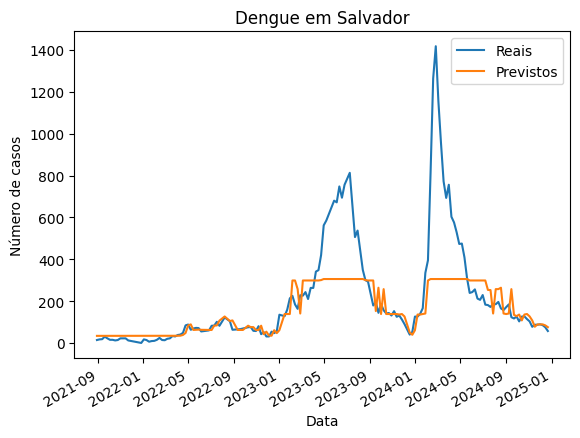

In [170]:
test_model(test[target], preds)

#Backtest

In [79]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train[target])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test[target], preds], axis=1)
    return combined

In [80]:
def backtest(data, model, predictors, start=468, step=52):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [171]:
predictions = backtest(df, model, predictors)

Random Forest
RMSE = 143.45386941601242


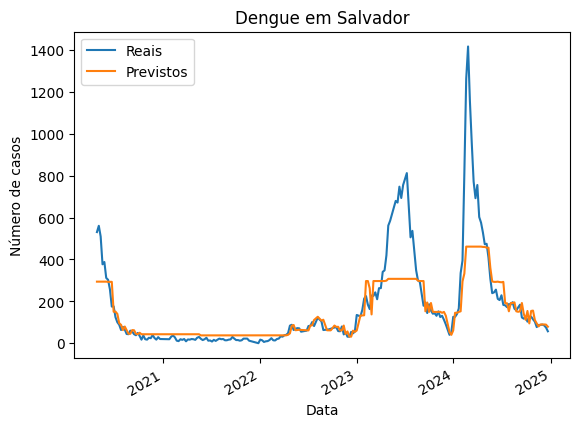

In [172]:
print("Random Forest")
test_model(predictions["casos"], predictions["Predictions"])

##Random Forest

In [83]:
# model = RandomForestRegressor(n_estimators=200, min_samples_split=100, random_state=1)
def best_RF(params):
  rmse = 100000000
  best_params = {"n_estimators": None, "min_samples_split": None}
  for n_value in params['n_estimators']:
    for min_sample_value in params['min_samples_split']:
      model = RandomForestRegressor(n_estimators=n_value, min_samples_split=min_sample_value, random_state=1)
      predictions = backtest(df, model, predictors)
      rmse_new = root_mean_squared_error(predictions['casos'], predictions['Predictions'])
      if rmse_new < rmse:
        rmse = rmse_new
        best_params["n_estimators"] = n_value
        best_params["min_samples_split"] = min_sample_value
  return best_params

In [173]:
Search = {'n_estimators': [2,3,4,5,10,20,50,100,200],
          'min_samples_split': [2,5,6,7,8,9,10,20,50,100,200]}
best_params = best_RF(Search)
print(best_params)

{'n_estimators': 2, 'min_samples_split': 6}


In [174]:
model = RandomForestRegressor(n_estimators=best_params['n_estimators'], min_samples_split=best_params['min_samples_split'], random_state=1)
predictions = backtest(df, model, predictors)

Random_Forest_Optimized
RMSE = 88.93905643964905


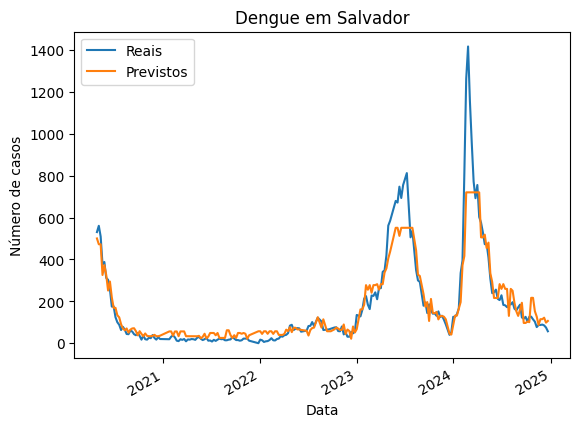

In [175]:
print("Random_Forest_Optimized")
test_model(predictions["casos"], predictions["Predictions"])

##SVR

In [34]:
model = SVR(kernel="rbf", gamma=0.1, C=1000)
predictions = backtest(df, model, predictors)

SVR
RMSE = 238.7230512379925


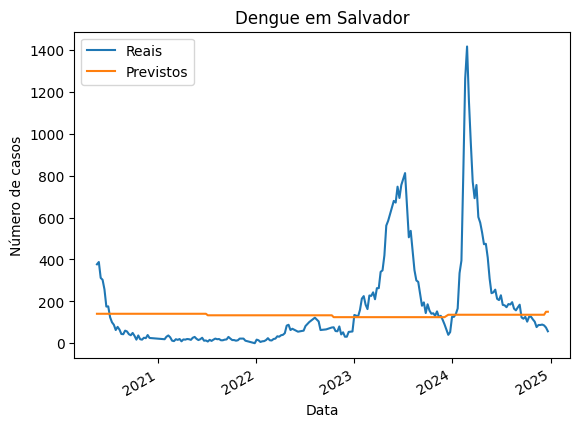

In [35]:
print("SVR")
test_model(predictions["casos"], predictions["Predictions"])

In [36]:
def best_SVR(params):
  rmse = 100000000
  best_params = {"kernel": None, "C": None, "gamma": None}
  for kernel_value in params['kernel']:
    for C_value in params['C']:
      for gamma_value in params['gamma']:
        model = SVR(kernel=kernel_value, gamma=gamma_value, C=C_value)
        predictions = backtest(df, model, predictors)
        rmse_new = root_mean_squared_error(predictions['casos'], predictions['Predictions'])
        if rmse_new < rmse:
          rmse = rmse_new
          best_params["C"] = C_value
          best_params["kernel"] = kernel_value
          best_params["gamma"] = gamma_value
  return best_params

In [37]:
Search = {'kernel': ["rbf"],
          'C': [1,10,10,100,1000,1500, 2000, 2500, 3000],
          'gamma': [1e-3, 1e-2, 1e-1, 0.2, 0.3, 0.4, 0.5]}
best_params = best_SVR(Search)
print(best_params)

{'kernel': 'rbf', 'C': 1000, 'gamma': 0.001}


In [39]:
model = SVR(kernel=best_params['kernel'], gamma=best_params['gamma'], C=best_params['C'])
predictions = backtest(df, model, predictors)

SVR_Optimized
RMSE = 222.35480695646905


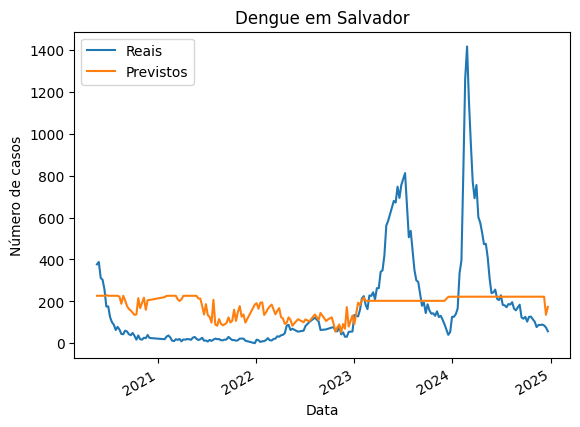

In [40]:
print("SVR_Optimized")
test_model(predictions["casos"], predictions["Predictions"])

# XGBoost

In [38]:
import xgboost as xgb

In [176]:
model = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                           n_estimators=1000,
                           objective='reg:squarederror',
                           max_depth=3,
                           min_child_weight = 1,
                           gamma = 0,
                          #  subsample = 0.8, colsample_bytree = 0.8,
                           scale_pos_weight = 1,
                           learning_rate=0.01)
predictions = backtest(df, model, predictors)

XGBoost
RMSE = 104.69987487792969


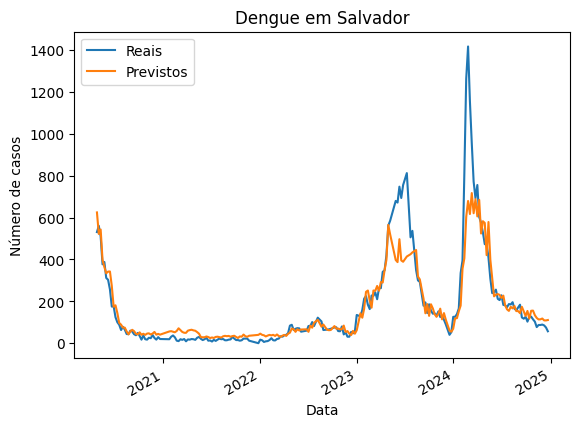

In [177]:
print("XGBoost")
test_model(predictions["casos"], predictions["Predictions"])

In [43]:
def best_XGBoost(params):
  rmse = 100000000
  best_params = {'max_depth': None, 'min_child_weight': None, "gamma": None}
  for max_depth_value in params['max_depth']:
    for min_child_weight_value in params['min_child_weight']:
      for gamma_value in params['gamma']:
        model = xgb.XGBRegressor(base_score=0.5, booster='gbtree', n_estimators=1000, objective='reg:squarederror', max_depth=max_depth_value, min_child_weight = min_child_weight_value, gamma = 0, scale_pos_weight = 1,
                                 learning_rate=0.01)
        predictions = backtest(df, model, predictors)
        rmse_new = root_mean_squared_error(predictions['casos'], predictions['Predictions'])
        if rmse_new < rmse:
          rmse = rmse_new
          best_params['max_depth'] = max_depth_value
          best_params['min_child_weight'] = min_child_weight_value
          best_params["gamma"] = gamma_value
  return best_params

In [178]:
Search = {
 'max_depth':range(3,10,1),
 'min_child_weight':range(1,6,1),
 'gamma':[0]
}
best_params = best_XGBoost(Search)
print(best_params)

{'max_depth': 3, 'min_child_weight': 5, 'gamma': 0}


In [218]:
model = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                           n_estimators=500,
                           objective='reg:squarederror',
                           max_depth=best_params['max_depth'],
                           min_child_weight = best_params['min_child_weight'],
                           gamma = 0.0,
                          #  subsample = 1, colsample_bytree = 1,
                           scale_pos_weight = 1,
                           learning_rate=0.01)
predictions = backtest(df, model, predictors)

XGBoost_Optimized
RMSE = 99.21044158935547


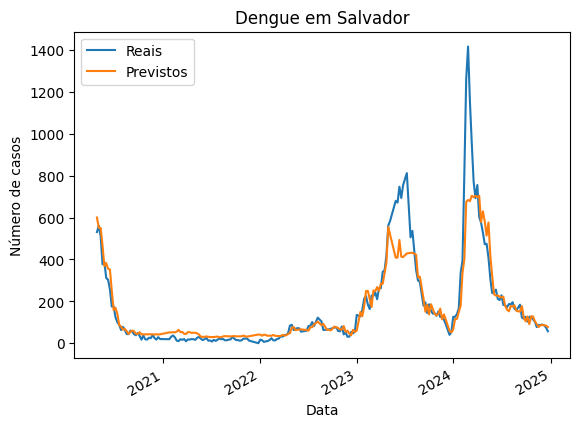

In [219]:
print("XGBoost_Optimized")
test_model(predictions["casos"], predictions["Predictions"])